# Hip Exo — gait-cycle hip moment profiles

Segments GPIO-synced hip exo trials into heel-strike (HS) gait cycles and plots mean hip joint moment (N·m/kg) profiles.

Builds on [`compare_processed_hip_exo_id.ipynb`](compare_processed_hip_exo_id.ipynb):

- **GT moment**: (Vicon ID + applied exo) / mass, causal 6 Hz LPF
- **Sync / trim**: GPIO falling-edge alignment; drop first/last 10 s post-sync
- **HS detection**: vertical GRF (plate 2 = right foot, 50 N threshold crossing)
- **§1b**: interactive QC of HS on GRF + hip flexion angle
- **§3 paper figure**: 2×4 angle + GT/pred moment by condition (LG 0.8/1.2/1.6, RA 0.8) + RMSE/R² heatmap


In [1]:
import io
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
# Keep axis/legend labels as editable text in vector exports (not paths)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
import numpy as np
import pandas as pd
from scipy.signal import butter, find_peaks, sosfilt, sosfiltfilt

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
PROCESSED_ROOT = Path('/media/metamobility3/Samsung_T52/Results/processed')
TELEMETRY_ROOT = PROJECT_ROOT

EXO_KIND = 'hip-exo'
JOINT = 'hip_flexion_r'
JOINT_LABEL = 'Hip R'
MOMENT_COL = 'hip_flexion_r_moment'
MOCAP_FS_HZ = 1000.0
LPF_CUTOFF_HZ, LPF_ORDER = 6.0, 4
GT_LPF_MODE = 'causal'
MODEL_LPF_MODE = 'zero_phase'
TELEMETRY_PATTERN = '*_hip_*_exo_on.npz'

SUBJECT_TOKEN_TO_DIR = {
    'ab01_jinwoo': 'AB01_Jinwoo', 'ab02_oscar': 'AB02_Oscar', 'ab03_ilseung': 'AB03_Ilseung',
    'ab04_changseob': 'AB04_Changseob', 'ab05_maria': 'AB05_Maria', 'ab06_jimin': 'AB06_Jimin',
    'ab07_amy': 'AB07_Amy', 'ab08_seokhyun': 'AB08_Seokhyun',
}
SUBJECT_MASS_KG = {
    'ab01_jinwoo': 88.0, 'ab02_oscar': 71.1, 'ab03_ilseung': 84.4, 'ab04_changseob': 74.0,
    'ab05_maria': 55.0, 'ab06_jimin': 82.6, 'ab07_amy': 51.3, 'ab08_seokhyun': 71.9,
}

CACHE_DIR = PROJECT_ROOT / 'analysis' / 'cache'
CACHE_PATH = CACHE_DIR / 'compare_processed_hip_exo_id.npz'
FIG_DIR = PROJECT_ROOT / 'analysis' / 'figures' / 'hip_exo_gait_cycles'

LOAD_FROM_CACHE = True
SAVE_TO_CACHE = False

TRIM_START_SEC = 10.0
TRIM_END_SEC = 10.0
EXCLUDE_SUBJECTS = set()  # include AB02_Oscar
EXCLUDE_TRIALS = {
    'ab05_maria_hip_1p6mps_lg_exo_on',  # corrupted ID
}

N_GAIT_PTS = 101
MIN_STRIDE_S = 0.40
MAX_STRIDE_S = 2.00
DEFAULT_FS_HZ = 100.0

SUBJECT_COLORS = {
    'AB01_Jinwoo': '#1f77b4',    # blue
    'AB02_Oscar': '#ff7f0e',     # orange
    'AB03_Ilseung': '#2ca02c',   # green
    'AB04_Changseob': '#d62728', # red
    'AB05_Maria': '#9467bd',     # purple
    'AB06_Jimin': '#8c564b',     # brown
    'AB07_Amy': '#e377c2',       # pink
    'AB08_Seokhyun': '#17becf',  # cyan
}
PAPER_CONDITIONS = ['LG_0p8mps', 'LG_1p2mps', 'LG_1p6mps', 'RA_0p8mps']
PAPER_CONDITION_LABELS = {
    'LG_0p8mps': 'LG 0.8',
    'LG_1p2mps': 'LG 1.2',
    'LG_1p6mps': 'LG 1.6',
    'RA_0p8mps': 'RA 0.8',
}
PRED_COLOR = '#c62828'  # dashed prediction
GT_COLOR = '#000000'
ANGLE_COLOR = '#1565c0'
ENCODER_COLOR = '#e65100'  # dotted encoder angle
STANCE_END_PCT = 60.0  # approximate toe-off shade

SUBJECT_LINE_ALPHA = 0.50  # More transparent individual lines
GRAND_MEAN_COLOR = '#000000'  # black for grand mean
GRAND_MEAN_STD_COLOR = '#999999'  # gray for ± std band
GRAND_MEAN_STD_ALPHA = 0.3

print(f'Joint: {JOINT_LABEL} | cache: {CACHE_PATH}')
print(f'LOAD_FROM_CACHE={LOAD_FROM_CACHE} | EXCLUDE_SUBJECTS={EXCLUDE_SUBJECTS} | '
      f'EXCLUDE_TRIALS={sorted(EXCLUDE_TRIALS)}')


Joint: Hip R | cache: /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_processed_hip_exo_id.npz
LOAD_FROM_CACHE=True | EXCLUDE_SUBJECTS=set() | EXCLUDE_TRIALS=['ab05_maria_hip_1p6mps_lg_exo_on']


In [2]:
def butter_lpf(x, fs_hz, cutoff_hz, order, mode='zero_phase'):
    arr = np.asarray(x, dtype=np.float64).reshape(-1)
    nyq = 0.5 * float(fs_hz)
    if cutoff_hz <= 0 or cutoff_hz >= nyq or len(arr) < 4:
        return arr
    sos = butter(int(order), float(cutoff_hz) / nyq, btype='low', output='sos')
    return sosfiltfilt(sos, arr) if mode == 'zero_phase' else sosfilt(sos, arr)


def lpf_nan(x, fs_hz, cutoff_hz, order, mode):
    arr = np.asarray(x, dtype=np.float64).copy()
    finite = np.isfinite(arr)
    if finite.sum() < max(3, order + 1):
        return arr
    if finite.all():
        return butter_lpf(arr, fs_hz, cutoff_hz, order, mode)
    idx = np.arange(arr.size, dtype=np.float64)
    filled = np.interp(idx, idx[finite], arr[finite])
    out = butter_lpf(filled, fs_hz, cutoff_hz, order, mode)
    out[~finite] = np.nan
    return out


def read_sto(path: Path):
    with open(path) as f:
        lines = f.readlines()
    end_idx = next(i for i, l in enumerate(lines) if l.strip().lower() == 'endheader')
    cols = lines[end_idx + 1].strip().split()
    data = np.loadtxt(io.StringIO(''.join(lines[end_idx + 2:])))
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return cols, data


def infer_fs_hz(time_s, default_fs=100.0):
    if time_s is None or len(time_s) < 3:
        return float(default_fs)
    dt = np.diff(np.asarray(time_s, dtype=np.float64))
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(1.0 / np.median(dt)) if dt.size else float(default_fs)


def _subject_token(stem: str) -> str:
    return '_'.join(stem.lower().split('_')[:2])


def subject_dir_from_stem(stem: str) -> Path:
    token = _subject_token(stem)
    name = SUBJECT_TOKEN_TO_DIR[token]
    p = PROCESSED_ROOT / name
    if not p.is_dir():
        raise FileNotFoundError(p)
    return p


def trial_cond_speed(stem: str) -> Tuple[str, str]:
    parts = stem.lower().split('_')
    return parts[4].upper(), parts[3]


def trial_meta_from_stem(stem: str) -> Dict[str, object]:
    token = _subject_token(stem)
    subject = SUBJECT_TOKEN_TO_DIR[token]
    cond, speed = trial_cond_speed(stem)
    condition = f'{cond}_{speed}'
    speed_mps = float(speed.replace('mps', '').replace('p', '.'))
    return {
        'subject': subject,
        'task': cond,
        'speed': speed,
        'condition': condition,
        'speed_mps': speed_mps,
        'trial_key': f'{subject}::{condition}',
    }


def is_excluded_subject(subject_name: str) -> bool:
    return EXCLUDE_SUBJECTS is not None and subject_name in EXCLUDE_SUBJECTS


def valid_telemetry_stem(stem: str) -> bool:
    token = _subject_token(stem)
    if token not in SUBJECT_TOKEN_TO_DIR:
        return False
    return not is_excluded_subject(SUBJECT_TOKEN_TO_DIR[token])


def analysis_trim_mask(
    t: np.ndarray,
    trim_start_s: float = TRIM_START_SEC,
    trim_end_s: float = TRIM_END_SEC,
) -> np.ndarray:
    t_rel = np.asarray(t, dtype=np.float64) - np.nanmin(t)
    t_end = float(np.nanmax(t_rel))
    return (t_rel >= float(trim_start_s)) & (t_rel <= t_end - float(trim_end_s))


def model_out_nmpkg_lpf(raw: np.ndarray, fs_hz: float) -> np.ndarray:
    return lpf_nan(raw, fs_hz, LPF_CUTOFF_HZ, LPF_ORDER, MODEL_LPF_MODE)


def enrich_model_out_nmpkg(wave: Dict) -> Dict:
    if 'model_out_nmpkg' in wave:
        return wave
    fs_hz = float(wave.get('fs_hz', infer_fs_hz(wave['t'])))
    out = dict(wave)
    out['fs_hz'] = fs_hz
    out['model_out_nmpkg'] = model_out_nmpkg_lpf(out['model_out_nmpkg_raw'], fs_hz)
    return out


def load_processed_exo_cache(path: Path = CACHE_PATH) -> Dict[str, Dict]:
    if not path.exists():
        raise FileNotFoundError(f'Cache not found: {path}')
    data = np.load(str(path), allow_pickle=True)
    trial_data: Dict[str, Dict] = {}
    for trial_key in data['trial_keys']:
        p = str(trial_key)
        meta = data[f'{p}__meta']
        wave = {
            'trial': p,
            'joint': str(meta[0]),
            'moment_col': str(meta[1]),
            'mass_kg': float(meta[2]),
            'offset_s': float(meta[3]),
            'applied_key': str(meta[4]),
            'gpio_key': str(meta[5]),
            'model_out_key': str(meta[6]),
            'trial_key': str(meta[7]),
            't': np.asarray(data[f'{p}__t'], dtype=np.float64),
            'gt_nmpkg': np.asarray(data[f'{p}__gt_nmpkg'], dtype=np.float64),
            'model_out_nmpkg_raw': np.asarray(data[f'{p}__model_out_nmpkg_raw'], dtype=np.float64),
        }
        if f'{p}__model_out_nmpkg' in data.files:
            wave['model_out_nmpkg'] = np.asarray(data[f'{p}__model_out_nmpkg'], dtype=np.float64)
        trial_data[p] = enrich_model_out_nmpkg(wave)
    print(f'Loaded {len(trial_data)} trials from {path}')
    return trial_data


print('Core helpers ready.')

Core helpers ready.


In [3]:
# HS detection (GRF-based: plate 2 = right foot)

GRF_FORCE_THRESHOLD_N = 50.0
GRF_RIGHT_FOOT_COLUMN = 'ground_force2_vy'

def lowpass_grf(x, fs, cutoff=20, order=2):
    """Light lowpass for GRF smoothing."""
    x = np.asarray(x, dtype=float)
    valid = np.isfinite(x)
    if valid.sum() < 10:
        return x.copy()
    nyq = 0.5 * float(fs)
    wn = float(np.clip(cutoff / nyq, 0.01, 0.99))
    sos = butter(int(order), wn, btype='low', output='sos')
    try:
        return sosfiltfilt(sos, x)
    except ValueError:
        return x.copy()


def detect_hs_from_grf(
    vy_force: np.ndarray,
    fs: float,
    force_threshold_n: float = GRF_FORCE_THRESHOLD_N,
    min_stride_time: float = MIN_STRIDE_S,
    max_stride_time: float = MAX_STRIDE_S,
) -> np.ndarray:
    """
    Detect right-foot heel strikes from vertical GRF (plate 2).
    
    Returns indices where vertical force crosses threshold from below (heel contact).
    """
    vy = np.asarray(vy_force, dtype=float)
    n = len(vy)
    if n < 10 or fs <= 0:
        return np.array([], dtype=int)
    
    # Smooth GRF slightly to remove high-freq noise
    vy_smooth = lowpass_grf(vy, fs, cutoff=20, order=2)
    
    # Find heel strikes: force crosses threshold from below
    above_thresh = vy_smooth >= force_threshold_n
    hs_candidates = []
    for i in range(1, n):
        if not above_thresh[i-1] and above_thresh[i]:
            hs_candidates.append(i)
    
    if len(hs_candidates) < 2:
        return np.array([], dtype=int)
    
    # Enforce min/max stride spacing (reject outliers)
    hs = [hs_candidates[0]]
    for idx in hs_candidates[1:]:
        dt = (idx - hs[-1]) / fs
        if min_stride_time <= dt <= max_stride_time:
            hs.append(idx)
    
    return np.array(hs, dtype=int) if len(hs) >= 2 else np.array([], dtype=int)


def load_grf_on_time(trial_stem: str, t_query: np.ndarray) -> np.ndarray:
    """
    Load vertical GRF for right foot (plate 2), interpolated onto t_query.
    
    Returns right-foot vertical force in Newtons.
    """
    cond, speed = trial_cond_speed(trial_stem)
    grf_path = subject_dir_from_stem(trial_stem) / EXO_KIND / 'grf' / f'{cond}_{speed}.mot'
    if not grf_path.exists():
        raise FileNotFoundError(f'GRF file not found: {grf_path}')
    cols, data = read_sto(grf_path)
    t_grf = data[:, cols.index('time')]
    vy_right = data[:, cols.index(GRF_RIGHT_FOOT_COLUMN)]
    vy_interp = np.interp(t_query, t_grf, vy_right, left=0.0, right=0.0)
    return vy_interp


def extract_signal_cycles(
    signal: np.ndarray,
    hs_events: np.ndarray,
    fs: float,
    n_pts: int = N_GAIT_PTS,
    min_stride_s: float = MIN_STRIDE_S,
    max_stride_s: float = MAX_STRIDE_S,
) -> Tuple[np.ndarray, np.ndarray]:
    """Resample HS→HS segments of a 1-D signal onto a 0–100% gait-cycle grid."""
    pct = np.linspace(0.0, 100.0, n_pts)
    cycles: List[np.ndarray] = []
    hs_events = np.asarray(hs_events, dtype=int)
    for i in range(len(hs_events) - 1):
        start, end = int(hs_events[i]), int(hs_events[i + 1])
        if end <= start:
            continue
        dur = (end - start) / fs
        if dur < min_stride_s or dur > max_stride_s:
            continue
        seg = np.asarray(signal[start:end], dtype=np.float64)
        if seg.size < 4 or not np.all(np.isfinite(seg)):
            continue
        src_pct = np.linspace(0.0, 100.0, seg.size)
        cycles.append(np.interp(pct, src_pct, seg))
    return np.asarray(cycles), pct


# Back-compat alias
extract_moment_cycles = extract_signal_cycles



def resolve_telemetry_path(stem: str) -> Path:
    """Prefer non-underscore telemetry; also check exo_telemetry/."""
    stem = stem.lstrip('_')
    search_roots = [TELEMETRY_ROOT, TELEMETRY_ROOT / 'exo_telemetry']
    for root in search_roots:
        for name in (f'{stem}.npz', f'_{stem}.npz'):
            p = root / name
            if p.is_file():
                return p
    raise FileNotFoundError(f'No telemetry for {stem} under {TELEMETRY_ROOT}')


def extract_encoder_hip_angle_deg(npz) -> Tuple[np.ndarray, str]:
    """Right-hip encoder angle in degrees from telemetry NPZ."""
    key = next(k for k in ('hip_pos_R', 'model_in_angle_raw_R', 'model_in_angle_raw') if k in npz.files)
    enc = np.asarray(npz[key], dtype=np.float64)
    # Stored in radians in exo telemetry
    if np.nanmax(np.abs(enc)) <= (2.0 * np.pi + 0.5):
        enc = np.rad2deg(enc)
    return enc, key


def load_encoder_angle_on_wave(trial_stem: str, wave: Dict) -> np.ndarray:
    """
    Encoder hip angle (deg) on the same sample grid as wave['t'] / gt_nmpkg.

    Cached waveforms use exo time + offset_s; encoder is logged on exo time, so
    index-align to the wave length (same as model_out).
    """
    npz = np.load(str(resolve_telemetry_path(trial_stem)), allow_pickle=True)
    enc_deg, _key = extract_encoder_hip_angle_deg(npz)
    n = len(wave['t'])
    if len(enc_deg) < n:
        out = np.full(n, np.nan)
        out[: len(enc_deg)] = enc_deg
        return out
    return np.asarray(enc_deg[:n], dtype=np.float64)

def load_ik_angle_on_time(trial_stem: str, t_query: np.ndarray, angle_col: str = JOINT) -> np.ndarray:
    """Load Vicon IK angle (deg), interpolated onto telemetry/mocap-synced t_query."""
    cond, speed = trial_cond_speed(trial_stem)
    ik_path = subject_dir_from_stem(trial_stem) / EXO_KIND / 'ik' / f'{cond}_{speed}_ik.mot'
    if not ik_path.exists():
        raise FileNotFoundError(f'IK file not found: {ik_path}')
    cols, data = read_sto(ik_path)
    if angle_col not in cols:
        raise KeyError(f'{angle_col} not in {ik_path.name}')
    t_ik = data[:, cols.index('time')]
    ang = data[:, cols.index(angle_col)]
    return np.interp(t_query, t_ik, ang, left=np.nan, right=np.nan)


def segment_trial_gait_cycles(trial_stem: str, wave: Dict) -> Optional[Dict]:
    meta = trial_meta_from_stem(trial_stem)
    t = np.asarray(wave['t'], dtype=np.float64)
    gt = np.asarray(wave['gt_nmpkg'], dtype=np.float64)
    model = np.asarray(wave['model_out_nmpkg'], dtype=np.float64)
    fs_hz = float(wave.get('fs_hz', infer_fs_hz(t, default_fs=DEFAULT_FS_HZ)))

    trim_mask = analysis_trim_mask(t)
    t_trim = t[trim_mask]
    gt_trim = gt[trim_mask]
    model_trim = model[trim_mask]
    if t_trim.size < 100:
        return None

    vy_right = load_grf_on_time(trial_stem, t_trim)
    hs_events = detect_hs_from_grf(vy_right, fs_hz)
    if hs_events.size < 3:
        return None

    gt_cycles, pct = extract_signal_cycles(gt_trim, hs_events, fs_hz)
    model_cycles, _ = extract_signal_cycles(model_trim, hs_events, fs_hz)
    if gt_cycles.size == 0 or model_cycles.size == 0:
        return None

    try:
        hip_deg = load_ik_angle_on_time(trial_stem, t_trim, angle_col=JOINT)
        angle_cycles, _ = extract_signal_cycles(hip_deg, hs_events, fs_hz)
        if angle_cycles.size == 0:
            angle_mean = np.full(N_GAIT_PTS, np.nan)
        else:
            n = min(len(angle_cycles), len(gt_cycles))
            angle_cycles = angle_cycles[:n]
            angle_mean = np.mean(angle_cycles, axis=0)
    except Exception:
        angle_cycles = np.empty((0, N_GAIT_PTS))
        angle_mean = np.full(N_GAIT_PTS, np.nan)

    try:
        enc_full = load_encoder_angle_on_wave(trial_stem, wave)
        enc_trim = enc_full[trim_mask]
        enc_cycles, _ = extract_signal_cycles(enc_trim, hs_events, fs_hz)
        if enc_cycles.size == 0:
            enc_mean = np.full(N_GAIT_PTS, np.nan)
        else:
            n = min(len(enc_cycles), len(gt_cycles))
            enc_cycles = enc_cycles[:n]
            enc_mean = np.mean(enc_cycles, axis=0)
    except Exception:
        enc_cycles = np.empty((0, N_GAIT_PTS))
        enc_mean = np.full(N_GAIT_PTS, np.nan)

    return {
        'trial': trial_stem,
        **meta,
        'fs_hz': fs_hz,
        'n_hs': int(hs_events.size),
        'n_cycles': int(gt_cycles.shape[0]),
        'pct': pct,
        'gt_cycles': gt_cycles,
        'model_cycles': model_cycles,
        'angle_cycles': angle_cycles,
        'encoder_cycles': enc_cycles,
        'gt_subject_mean': np.mean(gt_cycles, axis=0),
        'model_subject_mean': np.mean(model_cycles, axis=0),
        'angle_subject_mean': angle_mean,
        'encoder_subject_mean': enc_mean,
    }


print('HS + gait-cycle helpers ready (GRF-based detection + IK angle cycles).')


HS + gait-cycle helpers ready (GRF-based detection + IK angle cycles).


## 1. Load synced trial waveforms

In [4]:
if LOAD_FROM_CACHE:
    TRIAL_DATA = load_processed_exo_cache(CACHE_PATH)
else:
    raise RuntimeError(
        'Set LOAD_FROM_CACHE=True or run compare_processed_hip_exo_id.ipynb first '
        'to build the processed cache.'
    )

_before = len(TRIAL_DATA)
TRIAL_DATA = {
    stem: wave for stem, wave in TRIAL_DATA.items()
    if stem.lstrip('_') not in EXCLUDE_TRIALS
    and not is_excluded_subject(SUBJECT_TOKEN_TO_DIR[_subject_token(stem)])
}
_dropped = _before - len(TRIAL_DATA)
if _dropped:
    print(
        f'Excluded subjects/trials → dropped {_dropped} trial(s) '
        f'(subjects={sorted(EXCLUDE_SUBJECTS) if EXCLUDE_SUBJECTS else []}, '
        f'trials={sorted(EXCLUDE_TRIALS)})'
    )

print(f'Ready: {len(TRIAL_DATA)} trials')


Loaded 31 trials from /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_processed_hip_exo_id.npz
Ready: 31 trials


## 1b. Heel-strike QC (GRF + hip angle)

Heel strikes are detected from **vertical GRF** (`ground_force2_vy`, plate 2), not from joint angles. This viewer overlays:

1. **GRF** (detection signal) with threshold, raw rising-edge candidates, and stride-filtered HS  
2. **Hip flexion R** (Vicon IK) with the same HS markers for anatomical context  

Use this to spot missing / over-filtered events (e.g. stride duration outside `[MIN_STRIDE_S, MAX_STRIDE_S]`).


In [5]:
import ipywidgets as widgets
from IPython.display import display, clear_output

IK_ANGLE_COL = 'hip_flexion_r'


def detect_hs_candidates_from_grf(
    vy_force: np.ndarray,
    fs: float,
    force_threshold_n: float = GRF_FORCE_THRESHOLD_N,
) -> np.ndarray:
    """All rising-edge crossings (before min/max stride filtering)."""
    vy = np.asarray(vy_force, dtype=float)
    if len(vy) < 10 or fs <= 0:
        return np.array([], dtype=int)
    vy_smooth = lowpass_grf(vy, fs, cutoff=20, order=2)
    above = vy_smooth >= force_threshold_n
    return np.array(
        [i for i in range(1, len(vy)) if (not above[i - 1]) and above[i]],
        dtype=int,
    )


def build_hs_qc_row(trial_stem: str, wave: Dict) -> Dict:
    meta = trial_meta_from_stem(trial_stem)
    t = np.asarray(wave['t'], dtype=np.float64)
    fs_hz = float(wave.get('fs_hz', infer_fs_hz(t, default_fs=DEFAULT_FS_HZ)))
    trim_mask = analysis_trim_mask(t)
    t_trim = t[trim_mask]
    gt_trim = np.asarray(wave['gt_nmpkg'], dtype=np.float64)[trim_mask]

    vy = load_grf_on_time(trial_stem, t_trim)
    candidates = detect_hs_candidates_from_grf(vy, fs_hz)
    hs = detect_hs_from_grf(vy, fs_hz)
    stride_s = np.diff(hs) / fs_hz if hs.size >= 2 else np.array([])
    cand_stride_s = np.diff(candidates) / fs_hz if candidates.size >= 2 else np.array([])

    try:
        hip_deg = load_ik_angle_on_time(trial_stem, t_trim)
        ik_ok = True
        ik_err = ''
    except Exception as exc:
        hip_deg = np.full_like(t_trim, np.nan)
        ik_ok = False
        ik_err = str(exc)

    n_cycles = 0
    if hs.size >= 2:
        cycles, _ = extract_moment_cycles(gt_trim, hs, fs_hz)
        n_cycles = int(cycles.shape[0]) if cycles.size else 0

    flag = ''
    if candidates.size < 3:
        flag = 'few_candidates'
    elif hs.size < 3:
        flag = 'stride_filter_wiped_HS'
    elif n_cycles < 5:
        flag = 'few_cycles'
    elif hs.size < 20:
        flag = 'low_HS_count'

    return {
        **meta,
        'trial': trial_stem,
        'fs_hz': fs_hz,
        't_trim': t_trim,
        'vy': vy,
        'vy_smooth': lowpass_grf(vy, fs_hz, cutoff=20, order=2),
        'hip_deg': hip_deg,
        'gt_nmpkg': gt_trim,
        'candidates': candidates,
        'hs': hs,
        'n_candidates': int(candidates.size),
        'n_hs': int(hs.size),
        'n_cycles': n_cycles,
        'median_stride_s': float(np.median(stride_s)) if stride_s.size else np.nan,
        'median_cand_stride_s': float(np.median(cand_stride_s)) if cand_stride_s.size else np.nan,
        'ik_ok': ik_ok,
        'ik_err': ik_err,
        'flag': flag,
    }


HS_QC: Dict[str, Dict] = {}
HS_QC_WARNINGS: List[str] = []
for trial_stem, wave in sorted(TRIAL_DATA.items()):
    try:
        HS_QC[trial_stem] = build_hs_qc_row(trial_stem, wave)
    except Exception as exc:
        HS_QC_WARNINGS.append(f'{trial_stem}: {exc}')

hs_qc_df = pd.DataFrame([
    {
        'trial': r['trial'],
        'subject': r['subject'],
        'condition': r['condition'],
        'n_candidates': r['n_candidates'],
        'n_hs': r['n_hs'],
        'n_cycles': r['n_cycles'],
        'median_stride_s': r['median_stride_s'],
        'median_cand_stride_s': r['median_cand_stride_s'],
        'flag': r['flag'],
    }
    for r in HS_QC.values()
]).sort_values(['flag', 'n_hs', 'subject', 'condition'], ascending=[False, True, True, True])

print(
    f'HS QC built for {len(HS_QC)} / {len(TRIAL_DATA)} trials | '
    f'threshold={GRF_FORCE_THRESHOLD_N:.0f} N | stride∈[{MIN_STRIDE_S:.2f},{MAX_STRIDE_S:.2f}] s'
)
if HS_QC_WARNINGS:
    print('Warnings:')
    for msg in HS_QC_WARNINGS:
        print(' ', msg)

print('\nTrials with flags / low HS (inspection priority):')
display(hs_qc_df[hs_qc_df['flag'] != ''].reset_index(drop=True).round(3))
print('\nAll trials:')
display(hs_qc_df.reset_index(drop=True).round(3))

# --- interactive viewer ---
_trial_opts = [
    (f"{r['trial']}  [cand={r['n_candidates']} HS={r['n_hs']} cyc={r['n_cycles']}"
     + (f" | {r['flag']}" if r['flag'] else '') + "]", r['trial'])
    for r in sorted(HS_QC.values(), key=lambda x: (x['flag'] == '', x['n_hs'], x['trial']))
]
trial_dd = widgets.Dropdown(options=_trial_opts, description='Trial:', layout=widgets.Layout(width='720px'))
time_slider = widgets.FloatRangeSlider(
    description='Time (s):', continuous_update=False, layout=widgets.Layout(width='700px'),
)
show_cand_cb = widgets.Checkbox(value=True, description='Show raw candidates')
out = widgets.Output()


def _set_slider(trial_stem: str) -> None:
    t = HS_QC[trial_stem]['t_trim']
    t_rel = t - t[0]
    tmin, tmax = float(t_rel[0]), float(t_rel[-1])
    step = max((tmax - tmin) / 500, 1e-3)
    with time_slider.hold_sync():
        time_slider.min = tmin
        time_slider.max = tmax
        time_slider.step = step
        time_slider.value = (tmin, min(tmin + 20.0, tmax))  # first 20 s by default


def _draw(trial_stem: str, t_window, show_candidates: bool) -> None:
    r = HS_QC[trial_stem]
    t_rel = r['t_trim'] - r['t_trim'][0]
    t0, t1 = t_window
    hs = r['hs']
    cands = r['candidates']

    fig, axs = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    # 1) GRF detection signal
    ax = axs[0]
    ax.plot(t_rel, r['vy'], color='#90caf9', lw=0.8, alpha=0.7, label='GRF raw')
    ax.plot(t_rel, r['vy_smooth'], color='#1565c0', lw=1.4, label='GRF smooth')
    ax.axhline(GRF_FORCE_THRESHOLD_N, color='k', ls='--', lw=1.0, label=f'thresh={GRF_FORCE_THRESHOLD_N:.0f} N')
    if show_candidates and cands.size:
        ax.plot(t_rel[cands], r['vy_smooth'][cands], 'x', color='#fb8c00', ms=7, label=f'candidates ({cands.size})')
    if hs.size:
        ax.plot(t_rel[hs], r['vy_smooth'][hs], 'v', color='#c62828', ms=9, label=f'HS kept ({hs.size})')
    ax.set_ylabel('Fy (N)')
    ax.set_title('Right-foot vertical GRF (plate 2) — HS detection signal')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.set_xlim(t0, t1)

    # 2) Hip flexion angle with HS
    ax = axs[1]
    ax.plot(t_rel, r['hip_deg'], color='#2e7d32', lw=1.4, label='Vicon IK hip_flexion_r')
    if show_candidates and cands.size:
        ax.plot(t_rel[cands], r['hip_deg'][cands], 'x', color='#fb8c00', ms=7, label='candidates')
    if hs.size:
        ax.plot(t_rel[hs], r['hip_deg'][hs], 'v', color='#c62828', ms=9, label='HS kept')
        for idx in hs:
            ax.axvline(t_rel[idx], color='#c62828', lw=0.6, alpha=0.35)
    ax.set_ylabel('Angle (deg)')
    title_ik = 'Hip flexion R (context)'
    if not r['ik_ok']:
        title_ik += f' — IK load failed: {r["ik_err"]}'
    ax.set_title(title_ik)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(t0, t1)

    # 3) GT hip moment with HS
    ax = axs[2]
    ax.plot(t_rel, r['gt_nmpkg'], color='#6a1b9a', lw=1.4, label='GT hip moment')
    if hs.size:
        ax.plot(t_rel[hs], r['gt_nmpkg'][hs], 'v', color='#c62828', ms=9, label='HS kept')
        for idx in hs:
            ax.axvline(t_rel[idx], color='#c62828', lw=0.6, alpha=0.35)
    ax.set_ylabel('N·m/kg')
    ax.set_xlabel('Time since trim start (s)')
    ax.set_title('GT hip moment (segmented signal)')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(t0, t1)

    flag_txt = f" | flag={r['flag']}" if r['flag'] else ''
    fig.suptitle(
        f"{r['subject']}::{r['condition']} | cand={r['n_candidates']} HS={r['n_hs']} "
        f"cycles={r['n_cycles']} | med stride={r['median_stride_s']:.3f} s "
        f"(cand med={r['median_cand_stride_s']:.3f} s){flag_txt}",
        fontsize=12,
    )
    fig.tight_layout()
    with out:
        clear_output(wait=True)
        plt.show()


def _redraw(*_) -> None:
    if not trial_dd.value:
        return
    _draw(trial_dd.value, time_slider.value, show_cand_cb.value)


def _on_trial(change) -> None:
    _set_slider(change['new'])
    _redraw()


trial_dd.observe(_on_trial, names='value')
time_slider.observe(_redraw, names='value')
show_cand_cb.observe(_redraw, names='value')

if _trial_opts:
    _set_slider(trial_dd.value)
display(widgets.VBox([
    trial_dd,
    widgets.HBox([time_slider, show_cand_cb]),
    widgets.HTML(
        '<b>HS QC viewer</b> — red ▼ = kept heel strikes; orange × = raw GRF rising-edge candidates'
    ),
    out,
]))
_redraw()


HS QC built for 31 / 31 trials | threshold=50 N | stride∈[0.40,2.00] s

Trials with flags / low HS (inspection priority):


,trial,subject,condition,n_candidates,n_hs,n_cycles,median_stride_s,median_cand_stride_s,flag



All trials:


,trial,subject,condition,n_candidates,n_hs,n_cycles,median_stride_s,median_cand_stride_s,flag
0,ab08_seokhyun_hip_0p8mps_ra_exo_on,AB08_Seokhyun,RA_0p8mps,38,38,37,1.62,1.62,
1,ab02_oscar_hip_0p8mps_ra_exo_on,AB02_Oscar,RA_0p8mps,39,39,38,1.54,1.54,
2,ab03_ilseung_hip_0p8mps_ra_exo_on,AB03_Ilseung,RA_0p8mps,40,40,39,1.48,1.48,
3,ab04_changseob_hip_0p8mps_ra_exo_on,AB04_Changseob,RA_0p8mps,42,42,41,1.40,1.40,
4,ab06_jimin_hip_0p8mps_ra_exo_on,AB06_Jimin,RA_0p8mps,42,42,41,1.42,1.42,
5,ab03_ilseung_hip_0p8mps_lg_exo_on,AB03_Ilseung,LG_0p8mps,43,43,42,1.41,1.41,
6,ab08_seokhyun_hip_0p8mps_lg_exo_on,AB08_Seokhyun,LG_0p8mps,44,44,43,1.38,1.38,
7,ab05_maria_hip_0p8mps_ra_exo_on,AB05_Maria,RA_0p8mps,46,45,44,1.33,1.33,
8,ab02_oscar_hip_0p8mps_lg_exo_on,AB02_Oscar,LG_0p8mps,46,46,45,1.31,1.31,
9,ab05_maria_hip_0p8mps_lg_exo_on,AB05_Maria,LG_0p8mps,46,46,45,1.32,1.32,


## 2. Segment into HS gait cycles

In [6]:
GAIT_RESULTS: List[Dict] = []
SEGMENT_WARNINGS: List[str] = []

for trial_stem, wave in sorted(TRIAL_DATA.items()):
    try:
        result = segment_trial_gait_cycles(trial_stem, wave)
    except FileNotFoundError as exc:
        SEGMENT_WARNINGS.append(f'{trial_stem}: {exc}')
        continue
    except Exception as exc:
        SEGMENT_WARNINGS.append(f'{trial_stem}: {exc}')
        continue

    if result is None:
        SEGMENT_WARNINGS.append(f'{trial_stem}: no valid gait cycles')
        print(f'SKIP {trial_stem}: no valid gait cycles')
        continue

    GAIT_RESULTS.append(result)
    print(
        f"OK  {trial_stem} | {result['condition']} | "
        f"HS={result['n_hs']} cycles={result['n_cycles']}"
    )

for msg in SEGMENT_WARNINGS:
    print(msg)

GAIT_BY_CONDITION: Dict[str, List[Dict]] = defaultdict(list)
for row in GAIT_RESULTS:
    GAIT_BY_CONDITION[row['condition']].append(row)

summary_rows = [
    {
        'condition': cond,
        'n_subjects': len(trials),
        'n_cycles_total': int(sum(t['n_cycles'] for t in trials)),
        'n_cycles_mean': float(np.mean([t['n_cycles'] for t in trials])),
    }
    for cond, trials in sorted(GAIT_BY_CONDITION.items())
]
GAIT_SUMMARY_DF = pd.DataFrame(summary_rows)
display(GAIT_SUMMARY_DF)

OK  ab01_jinwoo_hip_0p8mps_lg_exo_on | LG_0p8mps | HS=51 cycles=50
OK  ab01_jinwoo_hip_0p8mps_ra_exo_on | RA_0p8mps | HS=50 cycles=49
OK  ab01_jinwoo_hip_1p2mps_lg_exo_on | LG_1p2mps | HS=57 cycles=56
OK  ab01_jinwoo_hip_1p6mps_lg_exo_on | LG_1p6mps | HS=62 cycles=61
OK  ab02_oscar_hip_0p8mps_lg_exo_on | LG_0p8mps | HS=46 cycles=45
OK  ab02_oscar_hip_0p8mps_ra_exo_on | RA_0p8mps | HS=39 cycles=38
OK  ab02_oscar_hip_1p2mps_lg_exo_on | LG_1p2mps | HS=54 cycles=53
OK  ab02_oscar_hip_1p6mps_lg_exo_on | LG_1p6mps | HS=58 cycles=57
OK  ab03_ilseung_hip_0p8mps_lg_exo_on | LG_0p8mps | HS=43 cycles=42
OK  ab03_ilseung_hip_0p8mps_ra_exo_on | RA_0p8mps | HS=40 cycles=39
OK  ab03_ilseung_hip_1p2mps_lg_exo_on | LG_1p2mps | HS=52 cycles=51
OK  ab03_ilseung_hip_1p6mps_lg_exo_on | LG_1p6mps | HS=58 cycles=57
OK  ab04_changseob_hip_0p8mps_lg_exo_on | LG_0p8mps | HS=47 cycles=46
OK  ab04_changseob_hip_0p8mps_ra_exo_on | RA_0p8mps | HS=42 cycles=41
OK  ab04_changseob_hip_1p2mps_lg_exo_on | LG_1p2mps | HS

,condition,n_subjects,n_cycles_total,n_cycles_mean
0,LG_0p8mps,8,364,45.500000
1,LG_1p2mps,8,430,53.750000
2,LG_1p6mps,7,418,59.714286
3,RA_0p8mps,8,336,42.000000


## 3. Paper figure — hip angle + moment by condition

Reference-style grid: **rows = conditions**, **columns = Angle | Moment**.

- Column headers with brackets; row group brackets for Level vs Ramp
- Mean ± SD ribbons; no subplot titles / no figure title
- Single bottom legend; x-label only on the bottom row


Saved → /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_exo_paper_angle_moment_by_condition.png (+ .pdf, .svg)


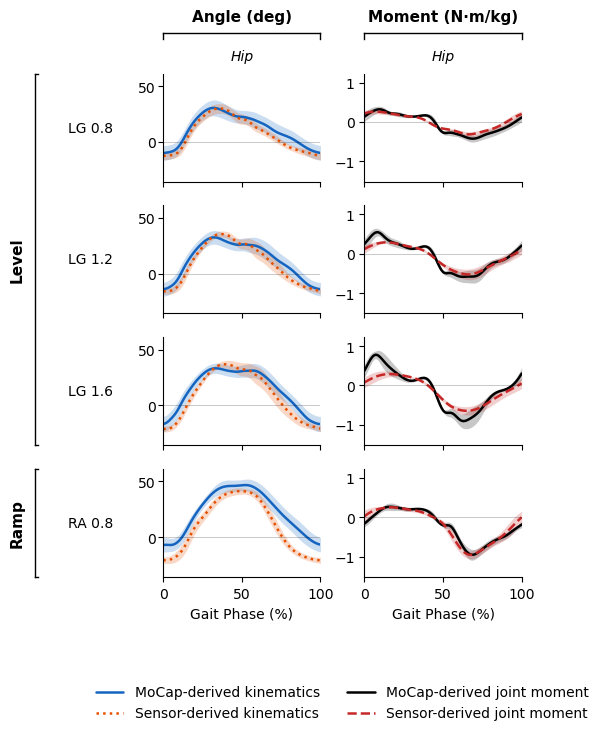

,condition,label,n_subjects,rmse_mean,rmse_sd,r2_mean,r2_sd
0,LG_0p8mps,LG 0.8,8,0.1093,0.0452,0.8007,0.1362
1,LG_1p2mps,LG 1.2,8,0.1471,0.0345,0.8295,0.0748
2,LG_1p6mps,LG 1.6,7,0.2424,0.0782,0.7676,0.0972
3,RA_0p8mps,RA 0.8,8,0.1277,0.0344,0.8881,0.0769


/tmp/ipykernel_3401660/2159389792.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved → /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_exo_paper_condition_metrics_heatmap.png (+ .pdf, .svg)


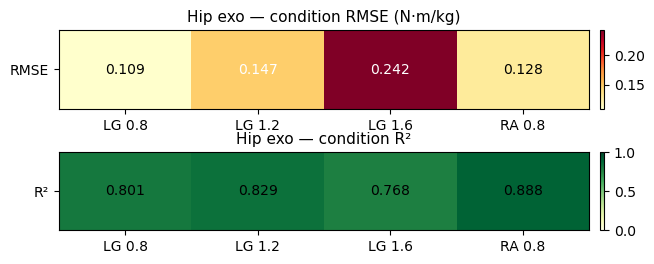

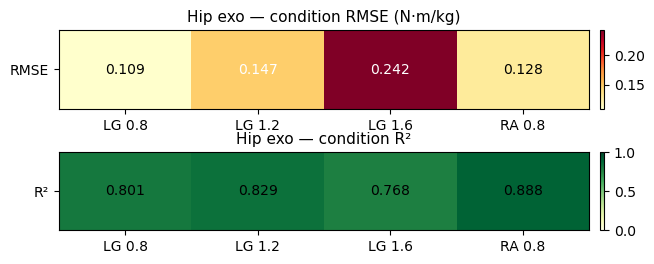

In [7]:
def _rmse_r2_1d(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    yt = np.asarray(y_true, dtype=np.float64).reshape(-1)
    yp = np.asarray(y_pred, dtype=np.float64).reshape(-1)
    m = np.isfinite(yt) & np.isfinite(yp)
    if m.sum() < 3:
        return float('nan'), float('nan')
    e = yp[m] - yt[m]
    rmse = float(np.sqrt(np.mean(e ** 2)))
    ss_res = float(np.sum(e ** 2))
    ss_tot = float(np.sum((yt[m] - np.mean(yt[m])) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 1e-12 else float('nan')
    return rmse, r2



def _paper_style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)




def _plot_mean_sd(ax, pct, stack, color, ls='-', lw=1.8, label=None, band_alpha=0.22):
    stack = np.asarray(stack, dtype=np.float64)
    if stack.size == 0:
        return
    mu = np.mean(stack, axis=0)
    sd = np.std(stack, axis=0, ddof=1) if stack.shape[0] > 1 else np.zeros_like(mu)
    ax.fill_between(pct, mu - sd, mu + sd, color=color, alpha=band_alpha, linewidth=0, zorder=1)
    ax.plot(pct, mu, color=color, lw=lw, ls=ls, solid_capstyle='round', label=label, zorder=2)


def _ylim_from_stacks(stacks, pad=0.10):
    vals = np.concatenate([np.asarray(s).ravel() for s in stacks if np.size(s)])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (-1.0, 1.0)
    lo, hi = float(np.min(vals)), float(np.max(vals))
    span = max(hi - lo, 1e-3)
    return lo - pad * span, hi + pad * span


def _draw_col_brackets(fig, axs, groups, sublabels=None):
    """groups: [(label, c0, c1), ...]. sublabels: [(text, col), ...] italic under brackets."""
    top_axs = axs[0, :]
    for label, c0, c1 in groups:
        p0, p1 = top_axs[c0].get_position(), top_axs[c1].get_position()
        x0, x1 = p0.x0, p1.x1
        y = p0.y1 + 0.055
        fig.add_artist(plt.Line2D([x0, x1], [y, y], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.add_artist(plt.Line2D([x0, x0], [y - 0.008, y], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.add_artist(plt.Line2D([x1, x1], [y - 0.008, y], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.text((x0 + x1) / 2, y + 0.012, label, ha='center', va='bottom',
                 fontsize=11, fontweight='bold', transform=fig.transFigure)
    if sublabels:
        for text, col in sublabels:
            p = top_axs[col].get_position()
            fig.text(
                0.5 * (p.x0 + p.x1), p.y1 + 0.014, text,
                ha='center', va='bottom', fontsize=10, fontstyle='italic',
                transform=fig.transFigure,
            )


def _draw_row_brackets(fig, axs, groups, x_offset=0.2):
    """Vertical group bracket + label well left of condition labels."""
    left = axs[:, 0]
    for label, r0, r1 in groups:
        p0, p1 = left[r0].get_position(), left[r1].get_position()
        x = p0.x0 - x_offset
        y0, y1 = p1.y0, p0.y1
        fig.add_artist(plt.Line2D([x, x], [y0, y1], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.add_artist(plt.Line2D([x, x + 0.005], [y0, y0], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.add_artist(plt.Line2D([x, x + 0.005], [y1, y1], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.text(x - 0.016, (y0 + y1) / 2, label, ha='right', va='center', rotation=90,
                 fontsize=11, fontweight='bold', transform=fig.transFigure)


def _draw_row_condition_labels(fig, axs, labels, x_offset=0.078):
    """Condition labels between group brackets and the axes."""
    left = axs[:, 0]
    for i, lab in enumerate(labels):
        p = left[i].get_position()
        fig.text(
            p.x0 - x_offset, 0.5 * (p.y0 + p.y1), lab,
            ha='right', va='center', fontsize=10, transform=fig.transFigure,
        )

def plot_hip_exo_paper_waveforms(
    gait_by_condition: Dict[str, List[Dict]],
    conditions: List[str] = None,
    save_path: Optional[Path] = None,
):
    """Paper figure: rows=conditions, cols=Angle | Moment (reference style)."""
    conditions = list(conditions or PAPER_CONDITIONS)
    n_row = len(conditions)
    pct = np.linspace(0.0, 100.0, N_GAIT_PTS)

    angle_means, enc_means, gt_means, pred_means = {}, {}, {}, {}
    for cond in conditions:
        trials = gait_by_condition.get(cond, [])
        ang = [np.asarray(t['angle_subject_mean'], dtype=np.float64)
               for t in trials if np.all(np.isfinite(t.get('angle_subject_mean', [np.nan])))]
        enc = [np.asarray(t['encoder_subject_mean'], dtype=np.float64)
               for t in trials if np.all(np.isfinite(t.get('encoder_subject_mean', [np.nan])))]
        gt = [np.asarray(t['gt_subject_mean'], dtype=np.float64) for t in trials]
        pr = [np.asarray(t['model_subject_mean'], dtype=np.float64) for t in trials]
        angle_means[cond] = np.vstack(ang) if ang else np.empty((0, N_GAIT_PTS))
        enc_means[cond] = np.vstack(enc) if enc else np.empty((0, N_GAIT_PTS))
        gt_means[cond] = np.vstack(gt) if gt else np.empty((0, N_GAIT_PTS))
        pred_means[cond] = np.vstack(pr) if pr else np.empty((0, N_GAIT_PTS))

    ylim_ang = _ylim_from_stacks(list(angle_means.values()) + list(enc_means.values()))
    ylim_mom = _ylim_from_stacks(list(gt_means.values()) + list(pred_means.values()))

    fig, axs = plt.subplots(
        n_row, 2, figsize=(6.4, 1.55 * n_row + 1.2),
        sharex=True, sharey='col',
        gridspec_kw={'wspace': 0.28, 'hspace': 0.22},
    )
    if n_row == 1:
        axs = np.asarray(axs).reshape(1, 2)

    legend_handles = []
    for i, cond in enumerate(conditions):
        # --- angle ---
        ax = axs[i, 0]
        _paper_style_ax(ax)
        _plot_mean_sd(ax, pct, angle_means[cond], ANGLE_COLOR, label='MoCap-derived kinematics' if i == 0 else None)
        _plot_mean_sd(ax, pct, enc_means[cond], ENCODER_COLOR, ls=':', label='Sensor-derived kinematics' if i == 0 else None)
        ax.set_ylim(*ylim_ang)
        ax.set_xlim(0, 100)
        ax.axhline(0, color='k', lw=0.5, alpha=0.30)
        if i == 0:
            legend_handles = ax.get_legend_handles_labels()
        if i == n_row - 1:
            ax.set_xlabel('Gait Phase (%)', fontsize=10)
        else:
            ax.tick_params(labelbottom=False)

        # --- moment ---
        ax = axs[i, 1]
        _paper_style_ax(ax)
        _plot_mean_sd(ax, pct, gt_means[cond], GT_COLOR, label='MoCap-derived joint moment' if i == 0 else None)
        _plot_mean_sd(ax, pct, pred_means[cond], PRED_COLOR, ls='--', label='Sensor-derived joint moment' if i == 0 else None)
        ax.set_ylim(*ylim_mom)
        ax.set_xlim(0, 100)
        ax.axhline(0, color='k', lw=0.5, alpha=0.30)
        if i == 0:
            # merge legend labels
            h2, l2 = ax.get_legend_handles_labels()
            if legend_handles:
                legend_handles = (legend_handles[0] + h2, legend_handles[1] + l2)
            else:
                legend_handles = (h2, l2)
        if i == n_row - 1:
            ax.set_xlabel('Gait Phase (%)', fontsize=10)
        else:
            ax.tick_params(labelbottom=False)

    for _ax in axs[:, 0]:
        _ax.tick_params(axis='y', pad=2)

    fig.subplots_adjust(left=0.22, right=0.78, top=0.82, bottom=0.14)
    _draw_col_brackets(
        fig, axs,
        [('Angle (deg)', 0, 0), ('Moment (N·m/kg)', 1, 1)],
        sublabels=[('Hip', 0), ('Hip', 1)],
    )
    # Level = first 3 LG, Ramp = RA
    level_idx = [i for i, c in enumerate(conditions) if c.startswith('LG_')]
    ramp_idx = [i for i, c in enumerate(conditions) if c.startswith('RA_') or c.startswith('RD_')]
    row_groups = []
    if level_idx:
        row_groups.append(('Level', level_idx[0], level_idx[-1]))
    if ramp_idx:
        row_groups.append(('Ramp', ramp_idx[0], ramp_idx[-1]))
    if row_groups:
        _draw_row_brackets(fig, axs, row_groups)
    _draw_row_condition_labels(
        fig, axs,
        [PAPER_CONDITION_LABELS.get(c, c) for c in conditions],
    )

    if legend_handles and legend_handles[0]:
        p0 = axs[-1, 0].get_position()
        p1 = axs[-1, 1].get_position()
        x_center = 0.5 * (p0.x0 + p1.x1)
        fig.legend(
            legend_handles[0], legend_handles[1],
            loc='upper center', ncol=2,
            frameon=False, fontsize=10, bbox_to_anchor=(x_center, 0.01),
        )

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        fig.savefig(save_path.with_suffix('.pdf'), bbox_inches='tight')
        fig.savefig(save_path.with_suffix('.svg'), bbox_inches='tight')
        print(f'Saved → {save_path} (+ .pdf, .svg)')
    plt.show()
    return fig


def compute_condition_metrics(gait_by_condition: Dict[str, List[Dict]], conditions: List[str] = None) -> pd.DataFrame:
    """Per-subject RMSE/R² on subject-mean cycles, then mean±SD across subjects per condition."""
    conditions = list(conditions or PAPER_CONDITIONS)
    rows = []
    for cond in conditions:
        rmses, r2s = [], []
        for t in gait_by_condition.get(cond, []):
            rmse, r2 = _rmse_r2_1d(t['gt_subject_mean'], t['model_subject_mean'])
            if np.isfinite(rmse):
                rmses.append(rmse)
            if np.isfinite(r2):
                r2s.append(r2)
        rows.append({
            'condition': cond,
            'label': PAPER_CONDITION_LABELS.get(cond, cond),
            'n_subjects': len(gait_by_condition.get(cond, [])),
            'rmse_mean': float(np.mean(rmses)) if rmses else np.nan,
            'rmse_sd': float(np.std(rmses, ddof=1)) if len(rmses) > 1 else 0.0,
            'r2_mean': float(np.mean(r2s)) if r2s else np.nan,
            'r2_sd': float(np.std(r2s, ddof=1)) if len(r2s) > 1 else 0.0,
        })
    return pd.DataFrame(rows)


def plot_hip_exo_metric_heatmap(metrics_df: pd.DataFrame, save_path: Optional[Path] = None):
    """Compact 2×4 heatmap: row0=RMSE, row1=R² across paper conditions."""
    labels = [PAPER_CONDITION_LABELS.get(c, c) for c in metrics_df['condition']]
    rmse = metrics_df['rmse_mean'].to_numpy(dtype=float)
    r2 = metrics_df['r2_mean'].to_numpy(dtype=float)
    data = np.vstack([rmse, r2])

    fig, axs = plt.subplots(2, 1, figsize=(7.2, 2.6), gridspec_kw={'hspace': 0.55})

    # RMSE
    im0 = axs[0].imshow(rmse.reshape(1, -1), aspect='auto', cmap='YlOrRd')
    axs[0].set_yticks([0])
    axs[0].set_yticklabels(['RMSE'])
    axs[0].set_xticks(range(len(labels)))
    axs[0].set_xticklabels(labels)
    for j, v in enumerate(rmse):
        axs[0].text(j, 0, f'{v:.3f}', ha='center', va='center', fontsize=10,
                    color='black' if v < np.nanmedian(rmse) else 'white')
    axs[0].set_title('Hip exo — condition RMSE (N·m/kg)', fontsize=11)
    fig.colorbar(im0, ax=axs[0], fraction=0.03, pad=0.02)

    # R²
    im1 = axs[1].imshow(r2.reshape(1, -1), aspect='auto', cmap='YlGn', vmin=0.0, vmax=1.0)
    axs[1].set_yticks([0])
    axs[1].set_yticklabels(['R²'])
    axs[1].set_xticks(range(len(labels)))
    axs[1].set_xticklabels(labels)
    for j, v in enumerate(r2):
        axs[1].text(j, 0, f'{v:.3f}', ha='center', va='center', fontsize=10,
                    color='white' if v < 0.55 else 'black')
    axs[1].set_title('Hip exo — condition R²', fontsize=11)
    fig.colorbar(im1, ax=axs[1], fraction=0.03, pad=0.02)

    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        fig.savefig(save_path.with_suffix('.pdf'), bbox_inches='tight')
        fig.savefig(save_path.with_suffix('.svg'), bbox_inches='tight')
        print(f'Saved → {save_path} (+ .pdf, .svg)')
    plt.show()
    return fig


# --- build / show ---
# --- ensure angle means exist (re-run §2 after updating hs-helpers) ---
_missing_angle = [
    t for trials in GAIT_BY_CONDITION.values() for t in trials
    if 'angle_subject_mean' not in t or not np.all(np.isfinite(t['angle_subject_mean']))
]
if _missing_angle:
    print(
        f'NOTE: {len(_missing_angle)} trial(s) lack angle_subject_mean — '
        're-run the HS-helpers + §2 segment cells, then re-run this cell.'
    )

missing = [c for c in PAPER_CONDITIONS if c not in GAIT_BY_CONDITION or not GAIT_BY_CONDITION[c]]
if missing:
    print('Warning: missing conditions for paper figure:', missing)

FIG_DIR.mkdir(parents=True, exist_ok=True)
plot_hip_exo_paper_waveforms(
    GAIT_BY_CONDITION,
    conditions=PAPER_CONDITIONS,
    save_path=FIG_DIR / 'hip_exo_paper_angle_moment_by_condition.png',
)

PAPER_METRICS_DF = compute_condition_metrics(GAIT_BY_CONDITION, PAPER_CONDITIONS)
display(PAPER_METRICS_DF.round(4))
PAPER_METRICS_DF.to_csv(CACHE_DIR / 'hip_exo_paper_condition_metrics.csv', index=False)

plot_hip_exo_metric_heatmap(
    PAPER_METRICS_DF,
    save_path=FIG_DIR / 'hip_exo_paper_condition_metrics_heatmap.png',
)


## 4. Plot model estimate gait-cycle hip moment profiles (exploratory)


Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_model_gait_cycle_LG_0p8mps.png (+ .svg)


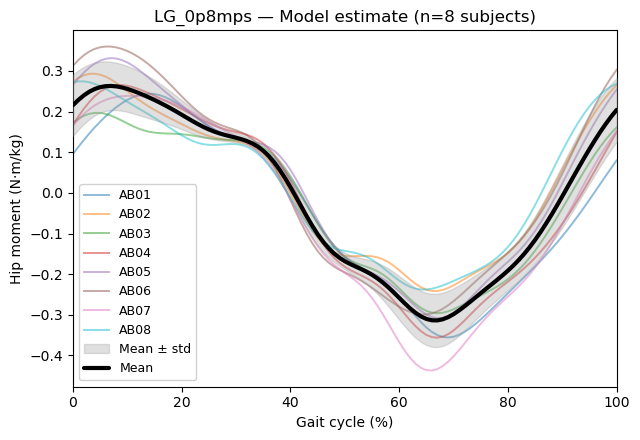

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_model_gait_cycle_LG_1p2mps.png (+ .svg)


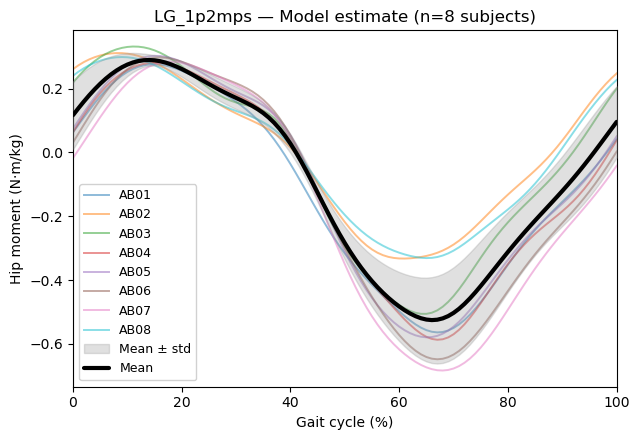

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_model_gait_cycle_LG_1p6mps.png (+ .svg)


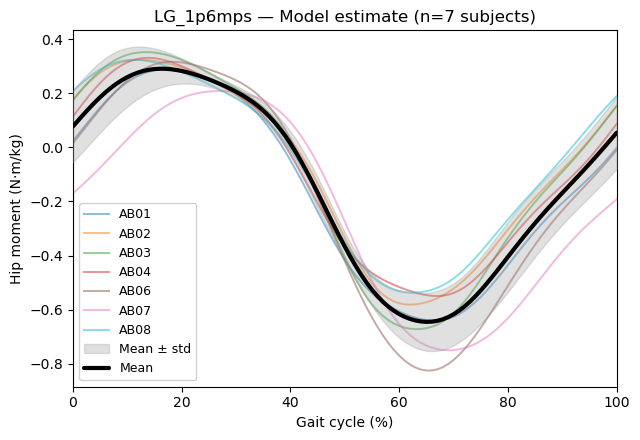

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_model_gait_cycle_RA_0p8mps.png (+ .svg)


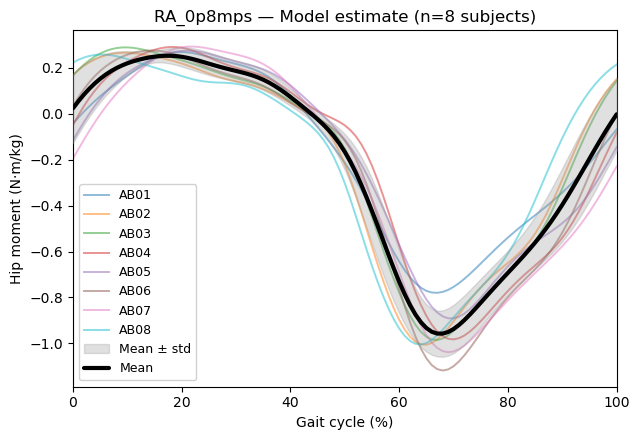

Saved overview → /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_model_gait_cycle_all_conditions.png (+ .svg)


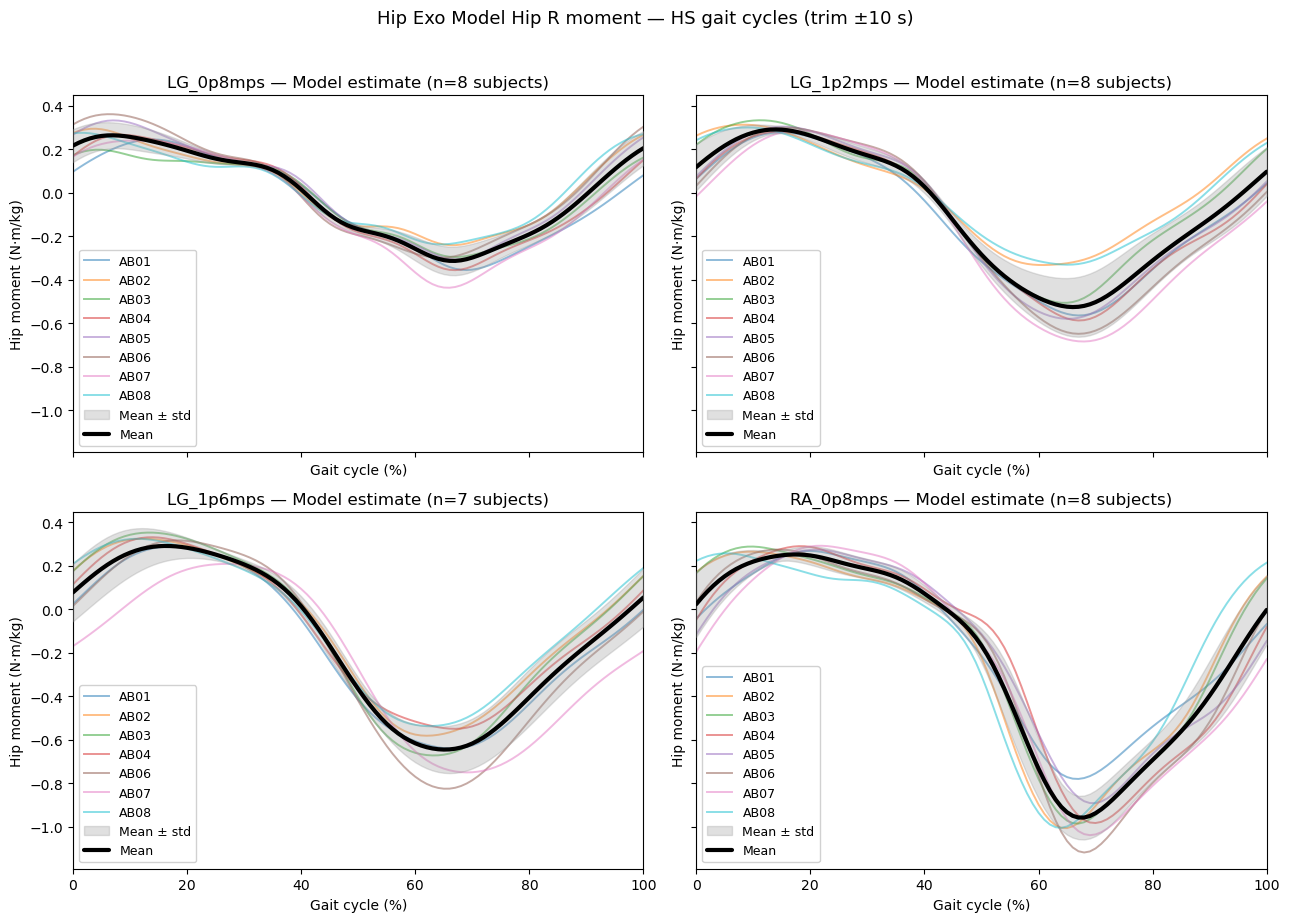

In [8]:
def plot_condition_model_cycles(
    condition: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    subject_means = [np.asarray(t['model_subject_mean'], dtype=np.float64) for t in trials]
    subjects = [t['subject'] for t in trials]
    grand_mean = np.mean(subject_means, axis=0)
    grand_std = np.std(subject_means, axis=0, ddof=1) if len(subject_means) > 1 else np.zeros_like(grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
    else:
        fig = ax.figure

    for subj, subj_mean in zip(subjects, subject_means):
        color = SUBJECT_COLORS.get(subj, '#999999')  # fallback gray
        subj_id = subj.split('_')[0]  # Extract AB01, AB03, etc.
        ax.plot(
            pct,
            subj_mean,
            color=color,
            alpha=SUBJECT_LINE_ALPHA,
            lw=1.4,
            label=subj_id,
        )

    # Plot grand mean ± std band
    ax.fill_between(
        pct,
        grand_mean - grand_std,
        grand_mean + grand_std,
        color=GRAND_MEAN_STD_COLOR,
        alpha=GRAND_MEAN_STD_ALPHA,
        label='Mean ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        grand_mean,
        color=GRAND_MEAN_COLOR,
        lw=3.0,
        solid_capstyle='round',
        label='Mean',
        zorder=10,
    )
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Hip moment (N·m/kg)')
    ax.set_title(f'{condition} — Model estimate (n={len(trials)} subjects)')
    
    # Add legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(loc='best', frameon=True, framealpha=0.9, fontsize=9)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            fig.savefig(save_path.with_suffix('.svg'), bbox_inches='tight')
            print(f'Saved {save_path} (+ .svg)')
        plt.show()

    return fig, ax, grand_mean


conditions = sorted(GAIT_BY_CONDITION.keys())
n_cond = len(conditions)
n_cols = 2
n_rows = int(np.ceil(n_cond / n_cols))

FIG_DIR.mkdir(parents=True, exist_ok=True)

# Save one figure per condition
for condition in conditions:
    plot_condition_model_cycles(
        condition,
        GAIT_BY_CONDITION[condition],
        save_path=FIG_DIR / f'hip_model_gait_cycle_{condition}.png',
    )

# Combined overview panel
fig_all, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.5 * n_rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, condition in zip(axes, conditions):
    plot_condition_model_cycles(
        condition,
        GAIT_BY_CONDITION[condition],
        ax=ax,
    )

for ax in axes[n_cond:]:
    ax.axis('off')

fig_all.suptitle(
    f'Hip Exo Model {JOINT_LABEL} moment — HS gait cycles (trim ±{TRIM_START_SEC:.0f} s)',
    y=1.02,
    fontsize=13,
)
fig_all.tight_layout()
overview_path = FIG_DIR / 'hip_model_gait_cycle_all_conditions.png'
fig_all.savefig(overview_path, dpi=150, bbox_inches='tight')
fig_all.savefig(overview_path.with_suffix('.svg'), bbox_inches='tight')
print(f'Saved overview → {overview_path} (+ .svg)')
plt.show()


## 5. GT vs Model comparison — grand means only (exploratory)


Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_gt_vs_model_comparison_LG_0p8mps.png (+ .svg)


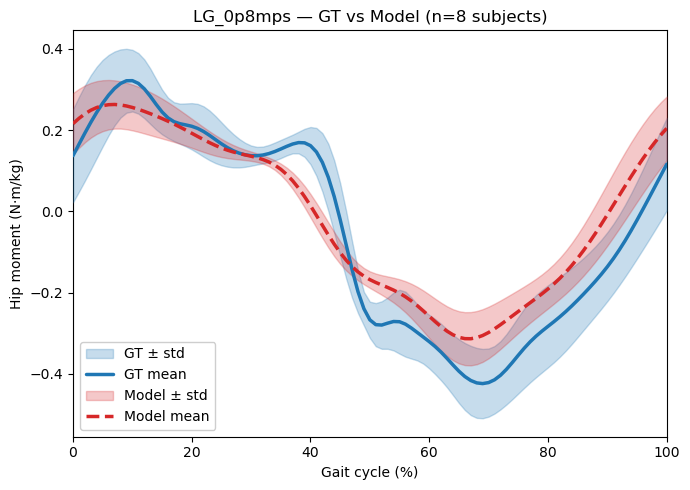

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_gt_vs_model_comparison_LG_1p2mps.png (+ .svg)


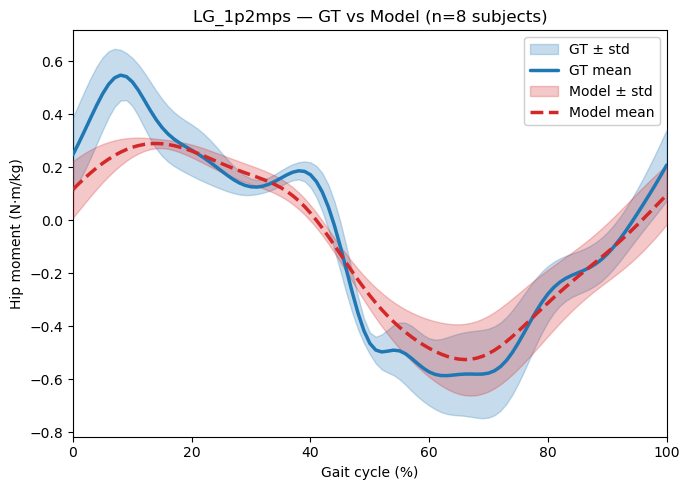

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_gt_vs_model_comparison_LG_1p6mps.png (+ .svg)


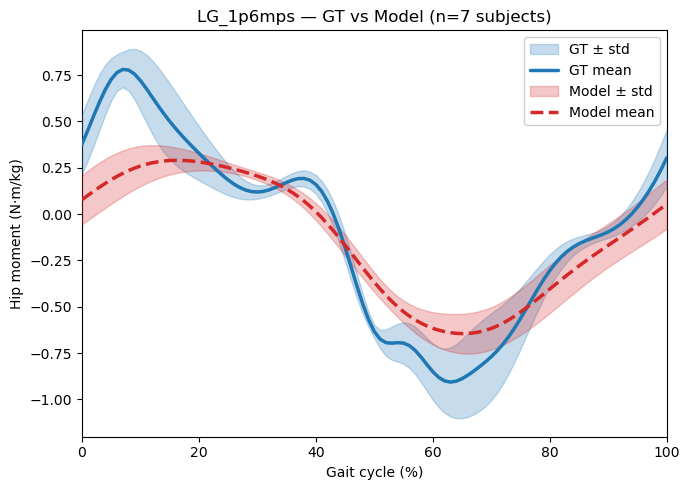

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_gt_vs_model_comparison_RA_0p8mps.png (+ .svg)


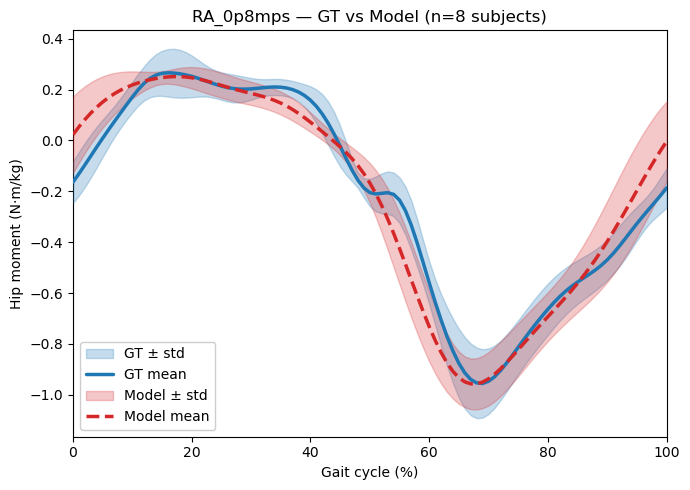

Saved overview → /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_gt_vs_model_comparison_all_conditions.png (+ .svg)


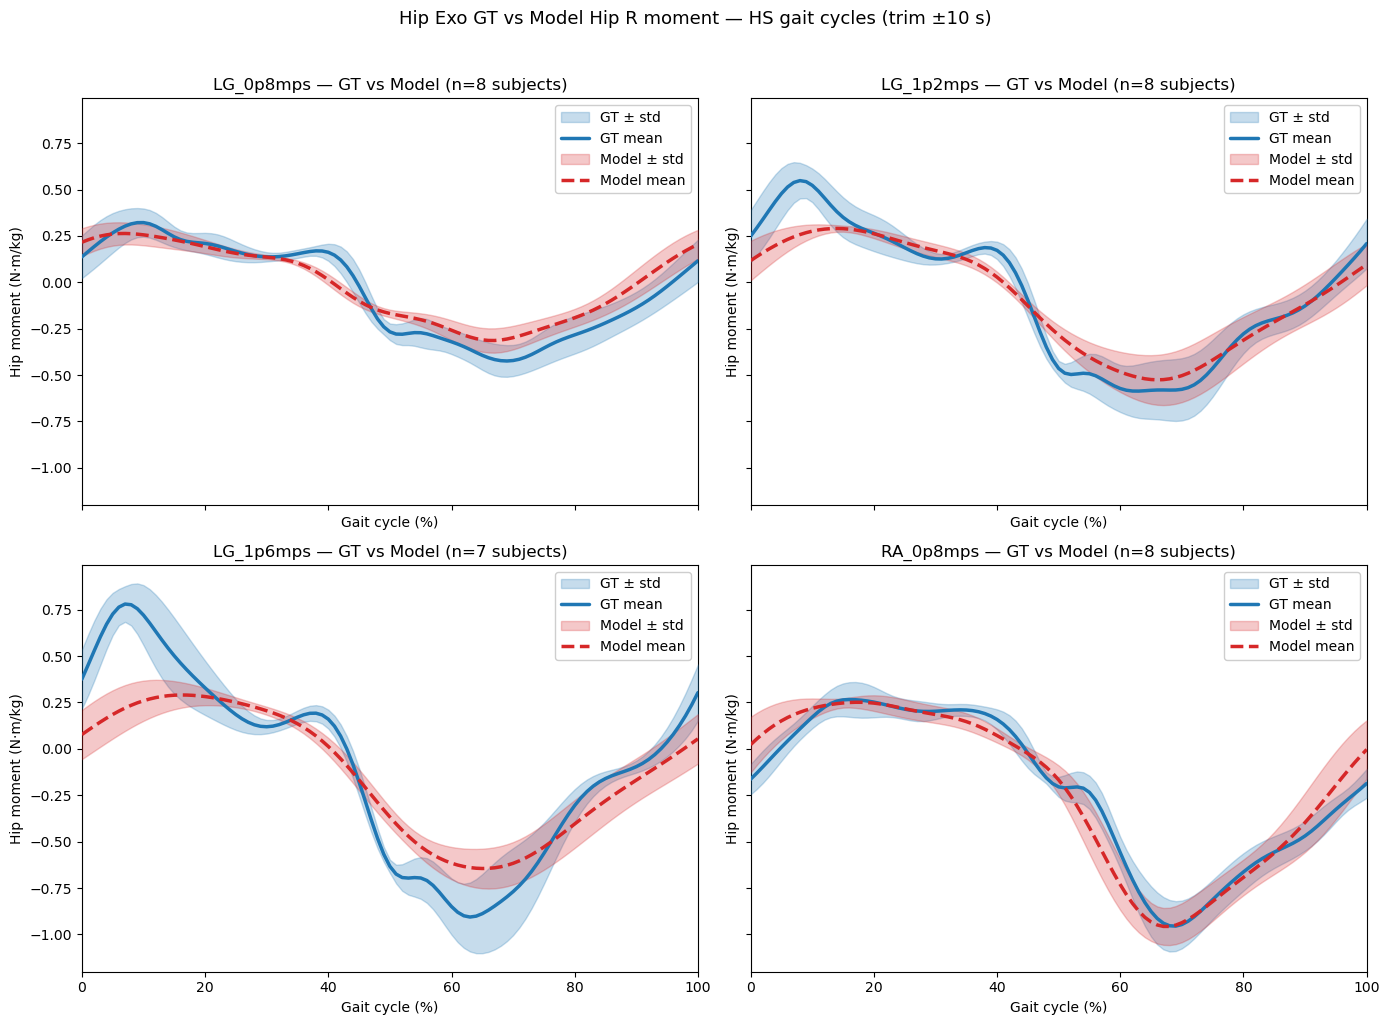

In [9]:
def plot_condition_gt_vs_model_comparison(
    condition: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    """Plot grand mean ± std for GT and model (no individual subjects)."""
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    
    # GT grand mean and std
    gt_subject_means = [np.asarray(t['gt_subject_mean'], dtype=np.float64) for t in trials]
    gt_grand_mean = np.mean(gt_subject_means, axis=0)
    gt_grand_std = np.std(gt_subject_means, axis=0, ddof=1) if len(gt_subject_means) > 1 else np.zeros_like(gt_grand_mean)
    
    # Model grand mean and std
    model_subject_means = [np.asarray(t['model_subject_mean'], dtype=np.float64) for t in trials]
    model_grand_mean = np.mean(model_subject_means, axis=0)
    model_grand_std = np.std(model_subject_means, axis=0, ddof=1) if len(model_subject_means) > 1 else np.zeros_like(model_grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    # Plot GT
    gt_color = '#1f77b4'  # blue
    ax.fill_between(
        pct,
        gt_grand_mean - gt_grand_std,
        gt_grand_mean + gt_grand_std,
        color=gt_color,
        alpha=0.25,
        label='GT ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        gt_grand_mean,
        color=gt_color,
        lw=2.5,
        solid_capstyle='round',
        label='GT mean',
        zorder=10,
    )
    
    # Plot Model
    model_color = '#d62728'  # red
    ax.fill_between(
        pct,
        model_grand_mean - model_grand_std,
        model_grand_mean + model_grand_std,
        color=model_color,
        alpha=0.25,
        label='Model ± std',
        zorder=6,
    )
    ax.plot(
        pct,
        model_grand_mean,
        color=model_color,
        lw=2.5,
        solid_capstyle='round',
        label='Model mean',
        zorder=11,
        linestyle='--',
    )
    
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Hip moment (N·m/kg)')
    ax.set_title(f'{condition} — GT vs Model (n={len(trials)} subjects)')
    ax.legend(loc='best', frameon=True, framealpha=0.95, fontsize=10)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            fig.savefig(save_path.with_suffix('.svg'), bbox_inches='tight')
            print(f'Saved {save_path} (+ .svg)')
        plt.show()

    return fig, ax


conditions = sorted(GAIT_BY_CONDITION.keys())
n_cond = len(conditions)
n_cols = 2
n_rows = int(np.ceil(n_cond / n_cols))

FIG_DIR.mkdir(parents=True, exist_ok=True)

# Save one figure per condition
for condition in conditions:
    plot_condition_gt_vs_model_comparison(
        condition,
        GAIT_BY_CONDITION[condition],
        save_path=FIG_DIR / f'hip_gt_vs_model_comparison_{condition}.png',
    )

# Combined overview panel
fig_all, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, condition in zip(axes, conditions):
    plot_condition_gt_vs_model_comparison(
        condition,
        GAIT_BY_CONDITION[condition],
        ax=ax,
    )

for ax in axes[n_cond:]:
    ax.axis('off')

fig_all.suptitle(
    f'Hip Exo GT vs Model {JOINT_LABEL} moment — HS gait cycles (trim ±{TRIM_START_SEC:.0f} s)',
    y=1.02,
    fontsize=13,
)
fig_all.tight_layout()
overview_path = FIG_DIR / 'hip_gt_vs_model_comparison_all_conditions.png'
fig_all.savefig(overview_path, dpi=150, bbox_inches='tight')
fig_all.savefig(overview_path.with_suffix('.svg'), bbox_inches='tight')
print(f'Saved overview → {overview_path} (+ .svg)')
plt.show()


Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_gt_gait_cycle_LG_0p8mps.png (+ .svg)


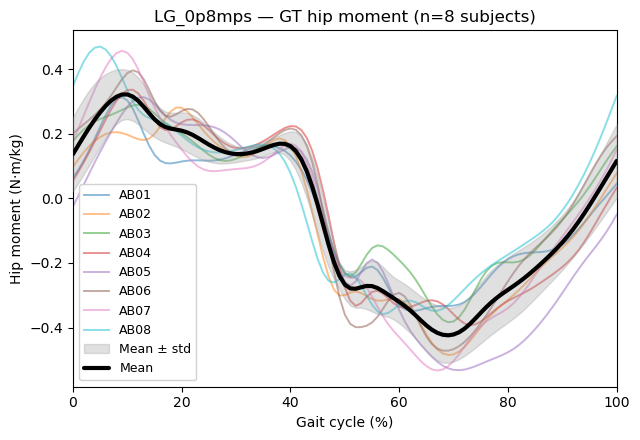

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_gt_gait_cycle_LG_1p2mps.png (+ .svg)


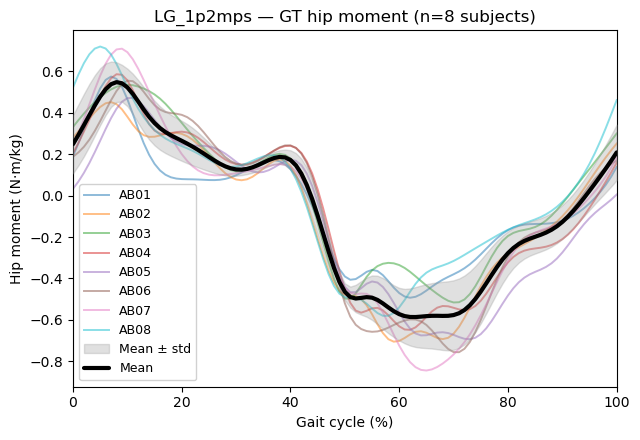

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_gt_gait_cycle_LG_1p6mps.png (+ .svg)


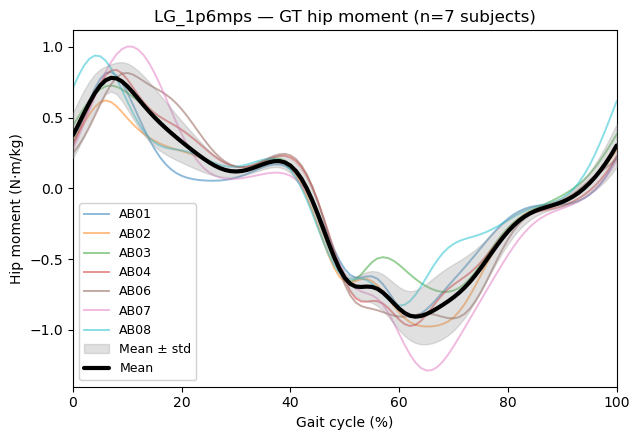

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_gt_gait_cycle_RA_0p8mps.png (+ .svg)


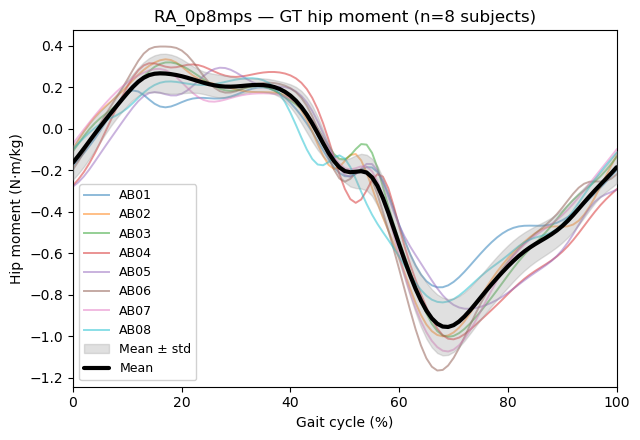

Saved overview → /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/hip_exo_gait_cycles/hip_gt_gait_cycle_all_conditions.png (+ .svg)


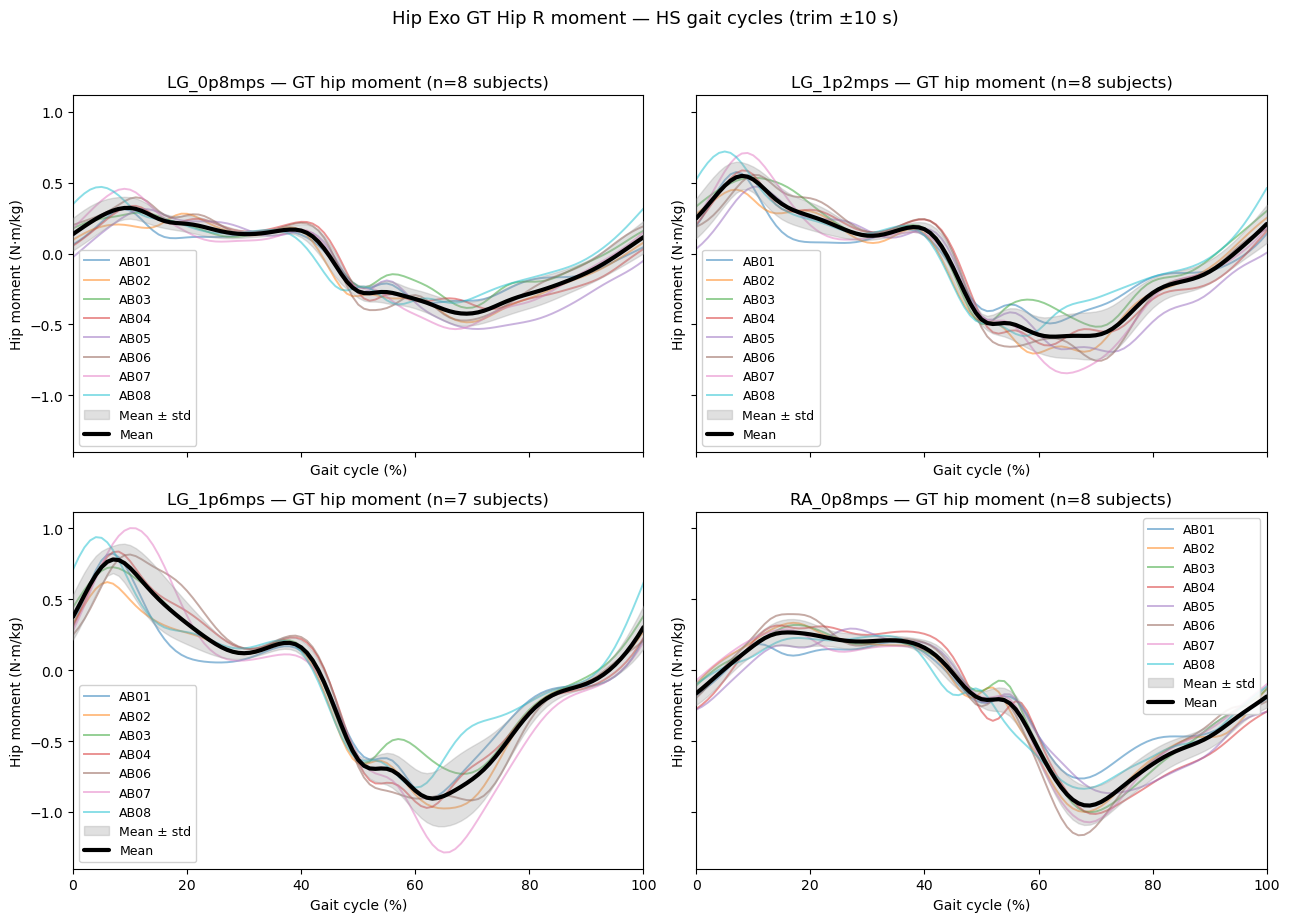

In [10]:
def plot_condition_gait_cycles(
    condition: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    subject_means = [np.asarray(t['gt_subject_mean'], dtype=np.float64) for t in trials]
    subjects = [t['subject'] for t in trials]
    grand_mean = np.mean(subject_means, axis=0)
    grand_std = np.std(subject_means, axis=0, ddof=1) if len(subject_means) > 1 else np.zeros_like(grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
    else:
        fig = ax.figure

    for subj, subj_mean in zip(subjects, subject_means):
        color = SUBJECT_COLORS.get(subj, '#999999')  # fallback gray
        subj_id = subj.split('_')[0]  # Extract AB01, AB03, etc.
        ax.plot(
            pct,
            subj_mean,
            color=color,
            alpha=SUBJECT_LINE_ALPHA,
            lw=1.4,
            label=subj_id,
        )

    # Plot grand mean ± std band
    ax.fill_between(
        pct,
        grand_mean - grand_std,
        grand_mean + grand_std,
        color=GRAND_MEAN_STD_COLOR,
        alpha=GRAND_MEAN_STD_ALPHA,
        label='Mean ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        grand_mean,
        color=GRAND_MEAN_COLOR,
        lw=3.0,
        solid_capstyle='round',
        label='Mean',
        zorder=10,
    )
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Hip moment (N·m/kg)')
    ax.set_title(f'{condition} — GT hip moment (n={len(trials)} subjects)')
    
    # Add legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(loc='best', frameon=True, framealpha=0.9, fontsize=9)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            fig.savefig(save_path.with_suffix('.svg'), bbox_inches='tight')
            print(f'Saved {save_path} (+ .svg)')
        plt.show()

    return fig, ax, grand_mean


conditions = sorted(GAIT_BY_CONDITION.keys())
n_cond = len(conditions)
n_cols = 2
n_rows = int(np.ceil(n_cond / n_cols))

FIG_DIR.mkdir(parents=True, exist_ok=True)

for condition in conditions:
    plot_condition_gait_cycles(
        condition,
        GAIT_BY_CONDITION[condition],
        save_path=FIG_DIR / f'hip_gt_gait_cycle_{condition}.png',
    )

fig_all, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.5 * n_rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, condition in zip(axes, conditions):
    plot_condition_gait_cycles(
        condition,
        GAIT_BY_CONDITION[condition],
        ax=ax,
    )

for ax in axes[n_cond:]:
    ax.axis('off')

fig_all.suptitle(
    f'Hip Exo GT {JOINT_LABEL} moment — HS gait cycles (trim ±{TRIM_START_SEC:.0f} s)',
    y=1.02,
    fontsize=13,
)
fig_all.tight_layout()
overview_path = FIG_DIR / 'hip_gt_gait_cycle_all_conditions.png'
fig_all.savefig(overview_path, dpi=150, bbox_inches='tight')
fig_all.savefig(overview_path.with_suffix('.svg'), bbox_inches='tight')
print(f'Saved overview → {overview_path} (+ .svg)')
plt.show()
